# Métodos de reducción de dimensionalidad

## Análisis factorial de datos mixtos (AFDM)

In [1]:
# Análisis factorial de datos mixtos (AFDM)

import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

# Datos: Trabajadores
datos = (
    pd.read_excel("Trabajadores.xlsx")
)

# Vista rápida
display(datos.head())

# Dimensión
datos.shape

Saving Trabajadores.xlsx to Trabajadores.xlsx


,Sexo,Edad,Estado,Hijos,Escolaridad,Estrato,Ingresos,Ayuda,Dependen,Egresos,Situación,Créditos,Conocimiento
0,F,45,Casado,2,Posgrado,4+,8.800,No,3,8.410,Buena,Sin Créditos,0.249
1,M,36,Casado,2,Pregrado,3,5.920,No,1,3.915,Buena,Vigentes,0.491
2,M,61,Casado,3,Técnico,2,2.256,Sí,2,2.390,Difícil,Vigentes,0.449
3,F,40,Viudo,2,Posgrado,2,5.706,No,2,3.480,Buena,Vigentes,0.506
4,F,49,Casado,3,Posgrado,4+,9.450,Sí,1,2.900,Buena,Vigentes,0.675


(168, 13)

In [4]:
# Análisis factorial de datos mixtos

# Uso de la función FAMD de la librería prince
!pip install prince
import prince

# Uso de la función FAMD
afdm = prince.FAMD(
    n_components=10,
    n_iter=10,
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=123
)

afdm = afdm.fit(datos)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 8.9 MB/s eta 0:00:00


,v. propio,inercia,iner. acum.
component,,,
0,14.796,4.65,4.65
1,12.743,4.01,8.66
2,11.077,3.48,12.14
3,10.551,3.32,15.46
4,9.903,3.11,18.58
5,9.629,3.03,21.60
6,9.091,2.86,24.46
7,8.880,2.79,27.25
8,8.766,2.76,30.01


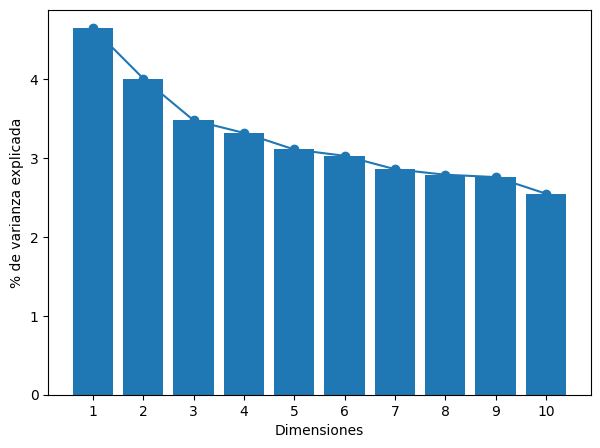

In [6]:
import matplotlib.pyplot as plt

# Valores propios y porcentajes de inercia
eig = afdm.eigenvalues_summary.copy()
eig.columns = ["v. propio", "inercia", "iner. acum."]

for col in ["inercia", "iner. acum."]:
    if eig[col].dtype == "O":
        eig[col] = eig[col].astype(str).str.replace("%", "", regex=False).astype(float)

display(eig)

# Histograma de valores propios (Scree Plot)

x = np.arange(1, eig.shape[0] + 1)

plt.figure(figsize=(7, 5))
plt.bar(x, eig["inercia"])
plt.plot(x, eig["inercia"], marker="o")
plt.xticks(x)
plt.xlabel("Dimensiones")
plt.ylabel("% de varianza explicada")
plt.show()

component,0,1,2,3,4,5,6,7,8,9
0,-0.694313,-6.762760,2.119201,-5.260930,2.016110,0.380345,3.863784,-0.207496,2.717002,1.560343
1,-1.734665,-1.041449,3.352984,-0.866156,-1.259769,-0.213168,0.504272,0.207443,-2.415375,-0.623471
2,-5.546710,-0.445584,-0.662567,3.809110,-5.808217,5.606470,-2.205864,-1.662902,2.988269,-0.413705
3,-1.517786,-3.957151,-8.195937,2.192273,-5.946451,-1.609700,4.407108,-2.581930,-0.772008,6.833451
4,-2.277720,-9.166954,-1.279963,1.642513,1.140426,5.056126,-3.466867,-0.079461,3.349561,-3.638075
...,...,...,...,...,...,...,...,...,...,...
163,-4.417603,7.678483,-1.666655,3.682170,3.760985,-1.208920,0.555260,-1.824840,4.182321,5.742673
164,-1.902451,-1.619942,-6.013997,1.198021,-8.169831,-2.291504,2.683546,-4.287262,-3.798523,7.066185
165,0.718970,3.682982,0.774517,-3.638727,1.855965,2.456943,-5.242543,5.859821,-1.003674,5.674378
166,-3.512645,7.019478,-1.247666,-1.143461,2.748507,1.278445,-0.889453,-4.024940,2.780611,4.985612


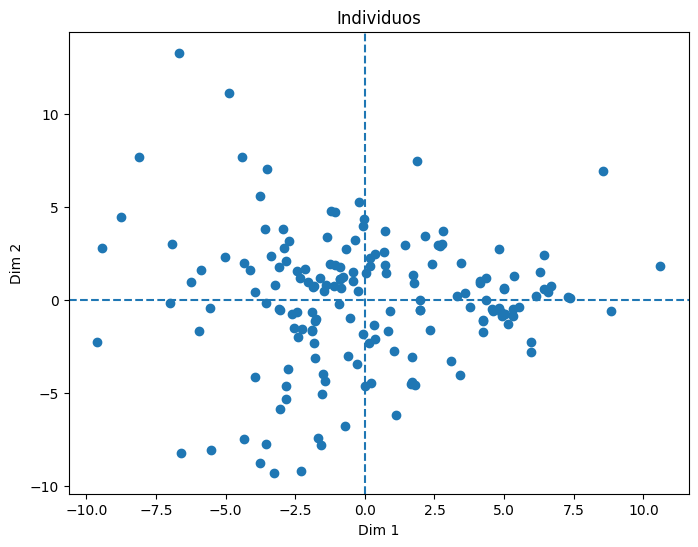

In [7]:
# Coordenadas de los individuos
coord_ind = afdm.row_coordinates(datos)
display(coord_ind)

# Representación de los individuos
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(coord_ind.iloc[:, 0], coord_ind.iloc[:, 1])
plt.axvline(x=0, linestyle="--")
plt.axhline(y=0, linestyle="--")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.title("Individuos")
plt.show()

component,0,1,2,3,4,5,6,7,8,9
Edad,0.690841,0.683311,0.616566,0.681000,0.790840,0.566242,0.772095,0.661224,0.743494,0.767579
Hijos,0.544928,0.371108,0.113896,0.516499,0.224634,0.282208,0.416554,0.117481,0.380275,0.089260
Ingresos,0.006174,0.583930,0.003157,0.024087,0.021197,0.000348,0.034033,0.005206,0.015421,0.004096
Dependen,0.481712,0.074290,0.411845,0.340622,0.120965,0.304751,0.056464,0.162668,0.050383,0.372917
Egresos,0.081196,0.264120,0.019219,0.012552,0.000236,0.020898,0.013237,0.001059,0.000897,0.003961
Conocimiento,0.000641,0.065346,0.003229,0.000015,0.035819,0.010502,0.000131,0.027524,0.001635,0.004513


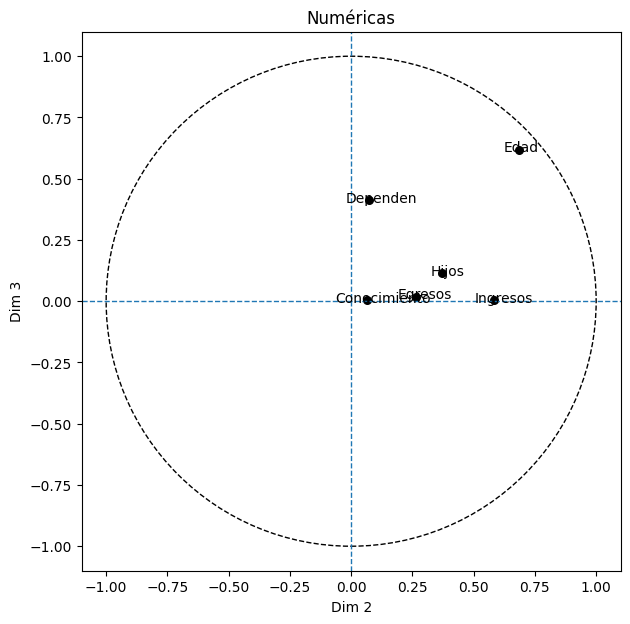

In [11]:
# Coordenadas de las variables numéricas
vars_num = datos.select_dtypes(include=np.number).columns
coord_quanti = afdm.column_coordinates_.loc[vars_num]
display(coord_quanti)

# Representación de las variables numéricas
!pip install adjustText
from adjustText import adjust_text
import matplotlib.pyplot as plt

x = coord_quanti.iloc[:, 1]
y = coord_quanti.iloc[:, 2]

fig, ax = plt.subplots(figsize=(7, 7))

circulo = plt.Circle((0, 0), 1, fill=False, linestyle="--", linewidth=1)
ax.add_artist(circulo)

ax.scatter(x, y, s=30, color="black")

texts = []
for nombre in coord_quanti.index:
    texts.append(ax.text(x.loc[nombre], y.loc[nombre], str(nombre), fontsize=10))

adjust_text(texts, ax=ax)

ax.axvline(0, linestyle="--", linewidth=1)
ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Dim 2")
ax.set_ylabel("Dim 3")
ax.set_title("Numéricas")

plt.show()

component,0,1,2,3,4,5,6,7,8,9
Sexo_F,-0.608102,-0.725530,-1.783109,0.394797,0.997501,0.098099,-0.834400,1.092839,0.087930,0.193666
Sexo_M,0.552820,0.659572,1.621008,-0.358907,-0.906819,-0.089181,0.758545,-0.993490,-0.079936,-0.176060
Estado_Casado,-1.822974,-0.620325,0.766856,-0.903331,-0.762575,0.348353,-0.766860,0.959035,-0.170834,-0.192186
Estado_Separado,-4.359530,3.420275,-1.271875,4.069344,5.023064,-1.353227,3.447162,0.808936,0.213958,0.931584
Estado_Soltero,4.481110,0.134708,0.885697,1.412615,-0.188135,-1.099208,0.251594,-0.151973,1.268327,-0.312573
Estado_Unión Libre,0.178561,0.758829,-1.829310,-2.023937,2.425605,1.929737,-0.295746,-2.792207,-1.089452,-0.779972
Estado_Viudo,-1.267643,-1.361455,-5.738367,1.423732,-5.100995,-1.031337,2.459666,-1.940076,-2.566659,4.665598
Escolaridad_Posgrado,0.815636,-2.561105,-1.035547,0.464307,1.654470,-1.120899,0.127290,-1.057068,1.950468,0.232581
Escolaridad_Pregrado,0.517806,0.031239,0.711645,-0.400642,-1.079655,0.370499,-0.405230,0.428210,-1.282545,-0.161432
Escolaridad_Técnico,-2.691880,3.374153,-0.777848,0.598713,1.067080,0.383236,1.069376,0.119902,1.287810,0.179601


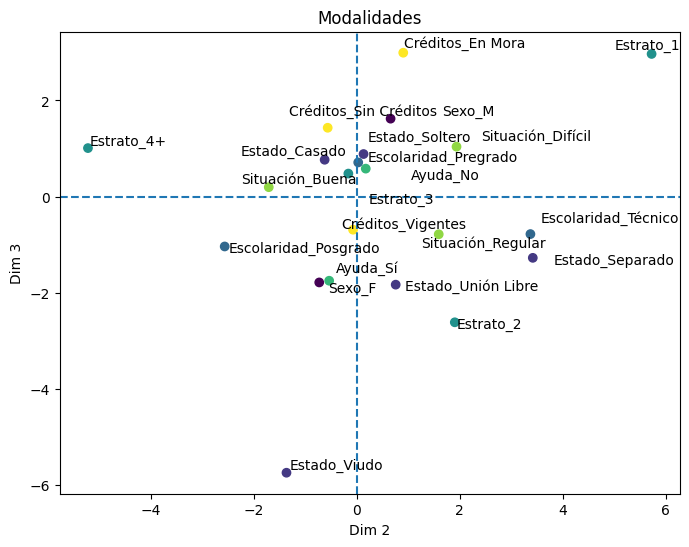

In [12]:
# Coordenadas de las modalidades de las variables categóricas
coord_ind = afdm.row_coordinates(datos)
vars_cat = datos.select_dtypes(exclude=np.number).columns

coord_quali = []

for var in vars_cat:
    aux = coord_ind.copy()
    aux[var] = datos[var].astype(str).values
    centros = aux.groupby(var).mean()
    centros.index = [f"{var}_{nivel}" for nivel in centros.index]
    coord_quali.append(centros)

coord_quali = pd.concat(coord_quali, axis=0)
display(coord_quali)

# Representación de las modalidades de las variables categóricas
col_var = np.repeat(np.arange(1, len(vars_cat) + 1), [datos[var].nunique() for var in vars_cat])

from adjustText import adjust_text
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(coord_quali.iloc[:, 1], coord_quali.iloc[:, 2], c=col_var)

texts = []
for i in coord_quali.index:
    texts.append(
        plt.text(
            coord_quali.loc[i].iloc[1],
            coord_quali.loc[i].iloc[2],
            str(i)
        )
    )

adjust_text(texts)

plt.axvline(x=0, linestyle="--")
plt.axhline(y=0, linestyle="--")
plt.xlabel("Dim 2")
plt.ylabel("Dim 3")
plt.title("Modalidades")
plt.show()

In [13]:
# Cosenos cuadrados
display(afdm.column_coordinates_.loc[afdm.num_cols_].round(3))  # var. numéricas

component,0,1,2,3,4,5,6,7,8,9
variable,,,,,,,,,,
Ingresos,0.006,0.584,0.003,0.024,0.021,0.000,0.034,0.005,0.015,0.004
Egresos,0.081,0.264,0.019,0.013,0.000,0.021,0.013,0.001,0.001,0.004
Conocimiento,0.001,0.065,0.003,0.000,0.036,0.011,0.000,0.028,0.002,0.005


In [14]:
# Contribuciones
vars_num = datos.select_dtypes(include=np.number).columns
vars_cat = datos.select_dtypes(exclude=np.number).columns

display(afdm.column_contributions_.loc[vars_num].round(3))  # var. numéricas
display(afdm.column_contributions_.loc[vars_cat].round(3))  # var. categóricas

component,0,1,2,3,4,5,6,7,8,9
Edad,0.047,0.054,0.056,0.065,0.080,0.059,0.085,0.074,0.085,0.095
Hijos,0.037,0.029,0.010,0.049,0.023,0.029,0.046,0.013,0.043,0.011
Ingresos,0.000,0.046,0.000,0.002,0.002,0.000,0.004,0.001,0.002,0.001
Dependen,0.033,0.006,0.037,0.032,0.012,0.032,0.006,0.018,0.006,0.046
Egresos,0.005,0.021,0.002,0.001,0.000,0.002,0.001,0.000,0.000,0.000
Conocimiento,0.000,0.005,0.000,0.000,0.004,0.001,0.000,0.003,0.000,0.001


component,0,1,2,3,4,5,6,7,8,9
Sexo,0.002,0.003,0.024,0.001,0.009,0.000,0.008,0.014,0.000,0.001
Estado,0.038,0.007,0.021,0.024,0.041,0.011,0.017,0.022,0.012,0.019
Escolaridad,0.008,0.023,0.005,0.002,0.016,0.005,0.004,0.005,0.028,0.001
Estrato,0.002,0.045,0.021,0.007,0.007,0.041,0.008,0.003,0.014,0.021
Ayuda,0.000,0.001,0.008,0.008,0.000,0.013,0.007,0.018,0.000,0.002
Situación,0.016,0.018,0.003,0.011,0.004,0.006,0.012,0.015,0.010,0.002
Créditos,0.018,0.001,0.014,0.001,0.007,0.004,0.008,0.017,0.001,0.004
